In [2]:
import os
import re

import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import sys 
import analysis_utils
sys.path.append("../")

from checkpoint import CheckPoint
from datasets import LetterStringDataLoader
import generate_data

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### New alphabets vs. training alphabets
- check that there training datasets and dataset containing the new alphabets share no permuted alphabets:

In [42]:
# check that training alphabets have no overlap with new alphabets:
df20 = pd.read_csv("../data/all_transformations_study1_copy_perm20/train.csv")
df40 = pd.read_csv("../data/all_transformations_study1_copy_perm40/train.csv")
df60 = pd.read_csv("../data/all_transformations_study1_copy_perm60/train.csv")
df80 = pd.read_csv("../data/all_transformations_study1_copy_perm80/train.csv")
df100 = pd.read_csv("../data/all_transformations_study1_copy_perm100/train.csv")
df140 = pd.read_csv("../data/all_transformations_study1_copy_perm140/train.csv")
df200 = pd.read_csv("../data/all_transformations_study1_copy_perm200/train.csv")
df400 = pd.read_csv("../data/all_transformations_study1_copy_perm400/train.csv")

all_training_alphabets = set(
    list(df20.alphabet.unique()) + 
    list(df40.alphabet.unique()) + 
    list(df60.alphabet.unique()) + 
    list(df80.alphabet.unique()) +
    list(df100.alphabet.unique()) +
    list(df140.alphabet.unique()) +
    list(df200.alphabet.unique()) +
    list(df400.alphabet.unique())
    )

df_new_alphs = pd.read_csv("../data/all_transformations_study1_new_alphabets/test.csv")
# only overlapping alphabet should be the standard alphabet:
all_training_alphabets & set(df_new_alphs.alphabet.unique())

{'a b c d e f g h i j k l m n o p q r s t u v w x y z'}

In [7]:
levenshtein_distances_by_dataset = []
for training_alphabets in [df20, df40, df60, df80, df100, df140, df200, df400]:
    min_levenshtein_distances = []
    for new_alph in df_new_alphs.alphabet.unique():
        min_levenshtein_dist = 1_000_000 # initialize with arbitrarily large number
        for train_alph in training_alphabets.alphabet.unique():
            levenshtein_dist = nltk.edit_distance(train_alph, new_alph)
            if levenshtein_dist < min_levenshtein_dist:
                min_levenshtein_dist = levenshtein_dist
        min_levenshtein_distances.append(min_levenshtein_dist)
    levenshtein_distances_by_dataset.append({
        "mean": np.mean(min_levenshtein_distances),
        "sd": np.std(min_levenshtein_distances)
    })

In [8]:
for perm_alphs, levenshtein_dist in zip(all_training_alphabets, levenshtein_distances_by_dataset):
    print(f"Training Dataset (with {perm_alphs} alphabets): Average minimum Levenshtein distance to new alphabets: {levenshtein_dist["mean"]:.2f} (sd: {levenshtein_dist["sd"]:.2f})")

Training Dataset (with j b c l e f g h i z k d m n o p q r s t u v w x y a alphabets): Average minimum Levenshtein distance to new alphabets: 8.52 (sd: 6.64)
Training Dataset (with a j p d e u g h i l k z m n o c x r s t f v w q y b alphabets): Average minimum Levenshtein distance to new alphabets: 8.38 (sd: 6.54)
Training Dataset (with d b c m e a s h i j x l t n o p q r g f u k w v y z alphabets): Average minimum Levenshtein distance to new alphabets: 8.24 (sd: 6.61)
Training Dataset (with a w c d e n g z i j k f m y t p q r s h u v o x b l alphabets): Average minimum Levenshtein distance to new alphabets: 8.19 (sd: 6.61)
Training Dataset (with a b g d l f h e y j k t s n o p q r c i u v w x m z alphabets): Average minimum Levenshtein distance to new alphabets: 8.05 (sd: 6.48)
Training Dataset (with k b c d e f g h i j a l m n o p q r s t u v w x y z alphabets): Average minimum Levenshtein distance to new alphabets: 7.86 (sd: 6.40)
Training Dataset (with s a c l e f g o i j k b m n d

# Num. seen alphabets/ batching method (5 replications)

In [5]:
def bootstrapped_confint(arr, n_samples:int = 10_000, alpha:float=0.05):
    # sample with replacement n_samples times and take the mean of each sample:
    samples = np.array([np.mean(np.random.choice(arr, size=len(arr), replace=True)) for _ in range(n_samples)])
    # sort means in ascending order:
    samples.sort()
    # get bootstrapped confidence interval boundaries:
    confint_low = samples[int(n_samples * (alpha / 2))]
    confint_upp = samples[int(n_samples * (1 - alpha / 2))]
    return confint_low, confint_upp

In [5]:
pattern = r'perm(\d+)_'
dir_path = "../models/num_permuted_alphabets"
training_runs = os.listdir(dir_path)
all_alph_runs = []
all_rand_runs = []
for run in training_runs:
    if "alph" in run:
        cp = CheckPoint.from_pt("/".join([dir_path,run]))
        perm = re.search(pattern, run)
        cp.num_perm_alphs = int(perm.group(1))
        all_alph_runs.append(cp)
    else:
        cp = CheckPoint.from_pt("/".join([dir_path,run]))
        perm = re.search(pattern, run)
        cp.num_perm_alphs = int(perm.group(1))
        all_rand_runs.append(cp)

In [6]:
all_training_runs = all_alph_runs
# add validation set accuracies for the last episode (i.e., on the trained alphabets)
data = [{**vars(train_run.train_config), **vars(train_run.mlc_config)} for train_run in all_training_runs]
for i, train_run in enumerate(all_training_runs):
    data[i]["seen transform."] = round([x["in"] for x in train_run.val_acc_hist][-1], 3)
    data[i]["new transform."] = round([x["out-of"] for x in train_run.val_acc_hist][-1], 3)
    data[i]["num. seen alphabets in training"] = train_run.num_perm_alphs
df = pd.DataFrame(data)
df["alphabets"] = "seen"

## Accuracy by num. seen alphabets (Figure 4)

In [ ]:
all_training_runs = all_alph_runs
# add validation set accuracies for the last episode (i.e., on the trained alphabets)
data = [{**vars(train_run.train_config), **vars(train_run.mlc_config)} for train_run in all_training_runs]
for i, train_run in enumerate(all_training_runs):
    data[i]["seen transform."] = round([x["in"] for x in train_run.val_acc_hist][-1], 3)
    data[i]["new transform."] = round([x["out-of"] for x in train_run.val_acc_hist][-1], 3)
    data[i]["num. seen alphabets in training"] = train_run.num_perm_alphs
df = pd.DataFrame(data)
df["alphabets"] = "seen"

# predictions on new set of permuted alphabets
accs_new_alphabets = pd.DataFrame(columns=["filename_model", "batching_method", "num. seen alphabets in training", "seen transform.", "new transform."])
test_new_alph = LetterStringDataLoader(
    mode="test", 
    data_dir="../data/all_transformations_study1_new_alphabets",
    batch_size=2000
)
for i, cp in enumerate(all_training_runs):
    model = cp.load_model(verbose=False)
    pred = analysis_utils.predict_dataset(test_new_alph, model, alternative_rule_errors=False)
    # exclude standard alphabet:
    pred = pred[pred["n_perm"]!= 0]
    test_acc_in = np.mean(pred[pred.distribution == "in"]["correct"])
    test_acc_out_of = np.mean(pred[pred.distribution == "out-of"]["correct"])
    accs_new_alphabets.loc[i,:] = [cp.train_config.filename_model, cp.train_config.batching_method, cp.num_perm_alphs, test_acc_in, test_acc_out_of]
accs_new_alphabets["alphabets"] = "new"

all_accs_alph = pd.concat([
    df[["filename_model", "batching_method", "num. seen alphabets in training", "seen transform.", "new transform.", "alphabets"]],
    accs_new_alphabets])

Generating predictions: 6it [02:26, 24.49s/it]                       
Generating predictions: 6it [02:35, 25.99s/it]                       
Generating predictions: 6it [02:40, 26.82s/it]                       
Generating predictions: 6it [02:41, 26.95s/it]                       
Generating predictions: 6it [02:34, 25.75s/it]                       
Generating predictions: 6it [02:33, 25.65s/it]                       
Generating predictions: 6it [02:34, 25.69s/it]                       
Generating predictions: 6it [02:32, 25.35s/it]                       
Generating predictions: 6it [02:36, 26.08s/it]                       
Generating predictions: 6it [02:01, 20.29s/it]                       
Generating predictions: 6it [02:00, 20.16s/it]                       
Generating predictions: 6it [02:14, 22.39s/it]                       
Generating predictions: 6it [02:23, 23.97s/it]                       
Generating predictions: 6it [01:55, 19.22s/it]                       
Generating predictio

Batching Method = alphabet


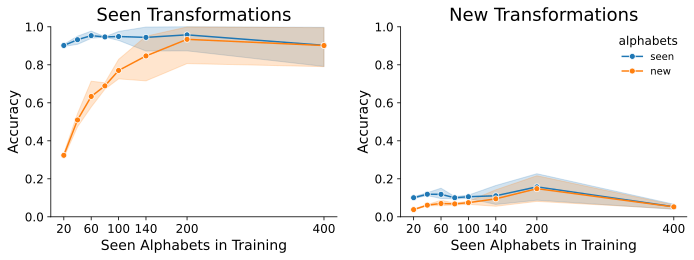

In [18]:
# Figure 4 (lower part)
print("Batching Method = alphabet")

plt.style.use("./figures_stylesheet.mplstyle")
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(10,4))
_ = sns.lineplot(all_accs_alph, 
                 x="num. seen alphabets in training", y="seen transform.", 
                 hue="alphabets", 
                 ax=ax[0], 
                 markers=True, 
                 marker="o",
                errorbar=bootstrapped_confint)
_ = ax[0].set_ylim((0,1))
_ = ax[0].set_xlabel("Seen Alphabets in Training")
_ = ax[0].set_xticks([20, 60, 100, 140, 200, 400])
_ = ax[0].set_ylabel("Accuracy")
_ = ax[0].legend().remove()
_ = ax[0].set_title("Seen Transformations")
_ = sns.lineplot(all_accs_alph, 
                x="num. seen alphabets in training", y="new transform.",   
                hue="alphabets", 
                ax=ax[1],
                markers=True, 
                marker="o",
                errorbar=bootstrapped_confint)
_ = ax[1].set_xlabel("Seen Alphabets in Training")
_ = ax[1].set_ylabel("Accuracy")
_ = ax[1].set_ylim((0,1))
_ = ax[1].set_title("New Transformations")

_ = fig.tight_layout(pad=2)

In [13]:
all_training_runs = all_rand_runs
# add validation set accuracies for the last episode (i.e., on the trained alphabets)
data = [{**vars(train_run.train_config), **vars(train_run.mlc_config)} for train_run in all_training_runs]
for i, train_run in enumerate(all_training_runs):
    data[i]["seen transform."] = round([x["in"] for x in train_run.val_acc_hist][-1], 3)
    data[i]["new transform."] = round([x["out-of"] for x in train_run.val_acc_hist][-1], 3)
    data[i]["num. seen alphabets in training"] = train_run.num_perm_alphs
df = pd.DataFrame(data)
df["alphabets"] = "seen"

# predictions on new set of permuted alphabets
accs_new_alphabets = pd.DataFrame(columns=["batching_method", "num. seen alphabets in training", "seen transform.", "new transform."])
for i, cp in enumerate(all_training_runs):
    model = cp.load_model(verbose=False)
    pred = analysis_utils.predict_dataset(test_new_alph, model, alternative_rule_errors=False)
    # exclude standard alphabet:
    pred = pred[pred["n_perm"]!= 0]
    test_acc_in = np.mean(pred[pred.distribution == "in"]["correct"])
    test_acc_out_of = np.mean(pred[pred.distribution == "out-of"]["correct"])
    accs_new_alphabets.loc[i,:] = [cp.train_config.batching_method, cp.num_perm_alphs, test_acc_in, test_acc_out_of]
accs_new_alphabets["alphabets"] = "new"

all_accs_rand = pd.concat([
    df[["batching_method", "num. seen alphabets in training", "seen transform.", "new transform.", "alphabets"]],
    accs_new_alphabets])

Generating predictions: 6it [01:30, 15.02s/it]                       
Generating predictions: 6it [02:17, 22.86s/it]                       
Generating predictions: 6it [01:48, 18.11s/it]                       
Generating predictions: 6it [02:18, 23.13s/it]                       
Generating predictions: 6it [02:17, 22.92s/it]                       
Generating predictions: 6it [02:01, 20.24s/it]                       
Generating predictions: 6it [03:11, 31.94s/it]                       
Generating predictions: 6it [02:41, 26.87s/it]                       
Generating predictions: 6it [02:41, 26.90s/it]                       
Generating predictions: 6it [02:32, 25.43s/it]                       
Generating predictions: 6it [02:48, 28.06s/it]                       
Generating predictions: 6it [03:14, 32.37s/it]                       
Generating predictions: 6it [02:42, 27.02s/it]                       
Generating predictions: 6it [02:53, 29.00s/it]                       
Generating predictio

Batching Method = random


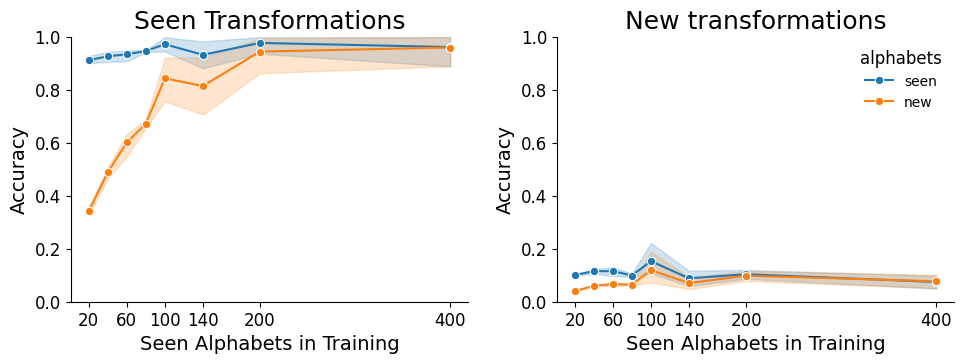

In [12]:
# Figure 4 (upper part)
print("Batching Method = random")
plt.style.use("./figures_stylesheet.mplstyle")
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(10,4))
_ = sns.lineplot(all_accs_rand, 
                 x="num. seen alphabets in training", y="seen transform.", 
                 hue="alphabets", 
                 ax=ax[0], 
                 markers=True, 
                 marker="o")
_ = ax[0].set_ylim((0,1))
_ = ax[0].set_xticks([20, 60, 100, 140, 200, 400])
_ = ax[0].set_xlabel("Seen Alphabets in Training")
_ = ax[0].set_ylabel("Accuracy")
_ = ax[0].legend().remove()
_ = ax[0].set_title("Seen Transformations")
_ = sns.lineplot(all_accs_rand, 
                x="num. seen alphabets in training", y="new transform.",   
                hue="alphabets", 
                ax=ax[1],
                markers=True, 
                marker="o",
                errorbar=bootstrapped_confint)
_ = ax[1].set_xlabel("Seen Alphabets in Training")
_ = ax[1].set_ylabel("Accuracy")
_ = ax[1].set_ylim((0,1))
_ = ax[1].set_title("New transformations")

_ = fig.tight_layout(pad=2)

In [ ]:
# save when running notebook for the first time to save computation time:
# all_accs_alph.to_csv("tables/num_seen_alphabets_batchalph.csv", index=False)
# all_accs_rand.to_csv("tables/num_seen_alphabets_batchrand.csv", index=False)

### Figure 4 as a Table:

In [17]:
all_accs_alph = pd.read_csv("tables/num_seen_alphabets_batchalph.csv")
all_accs_rand = pd.read_csv("tables/num_seen_alphabets_batchrand.csv")

In [102]:
# create dataframe with columns
alphabets = ["seen", "new"]
transformations = ["seen", "new"]

# Create MultiIndex for columns
columns = pd.MultiIndex.from_product([alphabets, transformations], names=["alphabets", "transformations"])

# Example data: 8 rows (for 8 training sizes), 4 columns (2x2)
data = np.random.rand(8, 4)

train_alph_levels = [20, 40, 60, 80, 100, 140, 200, 400]
# Create the DataFrame
df_batch_rand = pd.DataFrame("NA", index=train_alph_levels, columns=columns)
df_batch_rand.index.name = "num. seen alphabets in training"
df_batch_alph = df_batch_rand.copy(deep=True)

In [ ]:
bootstrapped_samples = 10_000

for train_alphs in train_alph_levels:
    df_train_alphs = all_accs_alph[all_accs_alph["num. seen alphabets in training"]==train_alphs]
    for alphs in ["seen", "new"]:
        for transforms in ["seen", "new"]:
            accs = df_train_alphs[df_train_alphs["alphabets"]==alphs][f"{transforms} transform."]
            mean_acc = np.mean(accs)
            # resample:
            acc_samples = np.array([np.mean(np.random.choice(accs, size=len(accs), replace=True)) for _ in range(bootstrapped_samples)])
            # sort ascending
            acc_samples.sort()
            # get bootstrapped confidence interval boundaries:
            ci_low = acc_samples[int(bootstrapped_samples * 0.025)]
            ci_upp = acc_samples[int(bootstrapped_samples * 0.975)]
            # multiply by 100 to convert to % for table
            df_batch_alph.loc[train_alphs, (alphs, transforms)] = f"{mean_acc*100:.1f} [{ci_low*100:.1f}, {ci_upp*100:.1f}]"

In [ ]:
for train_alphs in train_alph_levels:
    df_train_alphs = all_accs_rand[all_accs_rand["num. seen alphabets in training"]==train_alphs]
    for alphs in ["seen", "new"]:
        for transforms in ["seen", "new"]:
            accs = df_train_alphs[df_train_alphs["alphabets"]==alphs][f"{transforms} transform."]
            mean_acc = np.mean(accs)
            # resample with replacement and calculate means:
            acc_samples = np.array([np.mean(np.random.choice(accs, size=len(accs), replace=True)) for _ in range(bootstrapped_samples)])
            # sort ascending
            acc_samples.sort()
            # get bootstrapped confidence interval boundaries:
            ci_low = acc_samples[int(bootstrapped_samples * 0.025)]
            ci_upp = acc_samples[int(bootstrapped_samples * 0.975)]
            # multiply by 100 to convert to % for table
            df_batch_rand.loc[train_alphs, (alphs, transforms)] = f"{mean_acc*100:.1f} [{ci_low*100:.1f}, {ci_upp*100:.1f}]"

In [110]:
# Add batching_method as a new index level and concatenate
df_batch_rand_with_index = pd.concat(
    {"random": df_batch_rand}, names=["batching_method"]
)
df_batch_alph_with_index = pd.concat(
    {"alphabet": df_batch_alph}, names=["batching_method"]
)

# Combine both DataFrames
df_combined = pd.concat([df_batch_rand_with_index, df_batch_alph_with_index])

# Now df_combined has a MultiIndex with batching_method and num. seen alphabets in training
df_combined

alphabets                                                      seen  \
transformations                                                seen   
batching_method num. seen alphabets in training                       
random          20                                91.2 [90.0, 92.8]   
                40                                92.7 [90.6, 94.4]   
                60                                93.4 [90.8, 94.9]   
                80                                94.7 [94.2, 95.0]   
                100                               97.2 [94.5, 99.9]   
                140                               93.2 [88.2, 98.3]   
                200                               97.7 [93.6, 99.9]   
                400                              96.2 [88.9, 100.0]   
alphabet        20                                90.2 [89.7, 90.7]   
                40                                93.2 [90.8, 95.1]   
                60                                95.3 [93.9, 97.6]   
                80                                94.7 [94.6, 94.7]   
                100                               94.9 [92.8, 97.5]   
                140                               94.4 [87.2, 99.9]   
                200                              95.8 [87.3, 100.0]   
                400                               90.2 [79.1, 99.7]   

alphabets                                                           \
transformations                                                new   
batching_method num. seen alphabets in training                      
random          20                                10.1 [9.8, 10.3]   
                40                               11.5 [10.6, 12.4]   
                60                                11.5 [9.7, 13.0]   
                80                                 9.9 [9.2, 10.6]   
                100                              15.3 [10.7, 22.2]   
                140                                8.8 [5.9, 11.7]   
                200                               10.4 [8.6, 12.0]   
                400                                 7.5 [4.9, 9.8]   
alphabet        20                                10.0 [9.6, 10.5]   
                40                               11.9 [11.2, 12.7]   
                60                                11.8 [9.6, 14.8]   
                80                                10.0 [9.4, 10.6]   
                100                               10.6 [9.6, 11.4]   
                140                               11.1 [6.5, 16.6]   
                200                               15.8 [8.7, 22.6]   
                400                                 5.3 [4.0, 6.6]   

alphabets                                                      new  \
transformations                                               seen   
batching_method num. seen alphabets in training                      
random          20                               34.2 [32.7, 35.7]   
                40                               48.8 [46.5, 50.8]   
                60                               60.1 [54.9, 63.3]   
                80                               67.2 [65.3, 69.0]   
                100                              84.3 [75.9, 93.0]   
                140                              81.5 [70.7, 93.2]   
                200                              94.5 [86.3, 99.4]   
                400                              96.0 [88.7, 99.9]   
alphabet        20                               32.4 [31.4, 33.4]   
                40                               51.0 [47.4, 54.3]   
                60                               63.3 [57.7, 71.4]   
                80                               68.9 [67.2, 70.5]   
                100                              77.0 [72.6, 82.6]   
                140                              84.7 [72.4, 95.1]   
                200                              93.4 [80.6, 99.9]   
                400                              90.1 [79.0

## Accuracy by transformation (Table 2)

- Computed for models trained with 200 permuted alphabets including copy tasks with batching method = alphabet

In [ ]:
from generate_data import ALL_TRANSFORMATIONS

all_acc_by_trans = pd.DataFrame()
for i, train_run in enumerate(all_alph_runs):
    if train_run.num_perm_alphs == 200:
        acc_by_trans = pd.DataFrame({
            "transformation": train_run.val_acc_hist[-1].keys(), 
            "accuracy": train_run.val_acc_hist[-1].values()
        })
        all_acc_by_trans = pd.concat([all_acc_by_trans, acc_by_trans])

# remove aggregate accuracies:
all_acc_by_trans = all_acc_by_trans[~all_acc_by_trans["transformation"].isin(["epoch", "overall", "copy", "noncopy", "in", "out-of"])]

In [72]:
# sort by order as presented in the paper
trans_order = [trans["transformation"] for trans in ALL_TRANSFORMATIONS.values()][:-1]

# map transformation to generalization types (seen, compositional, novel)
gen_id2label = {0: "seen",
                2: "comp.",
                3: "novel"}
gen_type = {trans["transformation"]: gen_id2label[trans["generalization_type"]] for trans in ALL_TRANSFORMATIONS.values()}

table_acc_by_trans = pd.DataFrame(columns=["Type", "Transformation", "Accuracy (%)"])
for i, transform in enumerate(trans_order, 1):
    transform_rows = all_acc_by_trans[all_acc_by_trans["transformation"]==transform]
    mean_trans = transform_rows["accuracy"].mean()
    ci_low, ci_upp = bootstrapped_confint(transform_rows["accuracy"].values)
    new_row = pd.DataFrame({
        "Type": gen_type[transform], 
        "Transformation": transform, 
        "Accuracy (%)": f"{round(mean_trans * 100, 1)} [{round(ci_low * 100, 1)}, {round(ci_upp * 100, 1)}]"
    }, index=[i])
    table_acc_by_trans = pd.concat([table_acc_by_trans, new_row])
table_acc_by_trans.set_index("Type", drop=True, inplace=True)
table_acc_by_trans

,Transformation,Accuracy (%)
Type,,
seen,extend_sequence,"97.5 [92.6, 100.0]"
seen,succ,"97.1 [91.4, 100.0]"
seen,pred,"93.9 [81.7, 100.0]"
seen,remove_redundant,"100.0 [100.0, 100.0]"
seen,fix_alphabetic_seq,"89.5 [68.8, 100.0]"
seen,sort,"95.7 [87.0, 100.0]"
seen,sort_group,"95.6 [86.8, 100.0]"
seen,rr_interleave,"100.0 [100.0, 100.0]"
seen,rr_succ,"96.8 [90.4, 100.0]"


### Accuracies over Training (best model)

In [4]:
all_accs_alph.sort_values("new transform.", ascending=False)

,batching_method,num. seen alphabets in training,seen transform.,new transform.,alphabets
10,alphabet,200,1.000000,0.271000,seen
50,alphabet,200,0.998728,0.262257,new
12,alphabet,200,1.000000,0.215000,seen
5,alphabet,140,1.000000,0.215000,seen
52,alphabet,200,0.999682,0.194963,new
...,...,...,...,...,...
51,alphabet,200,0.679281,0.036531,new
58,alphabet,20,0.328033,0.036147,new
57,alphabet,20,0.329623,0.035186,new
55,alphabet,20,0.304500,0.034993,new


In [2]:
best_cp = CheckPoint.from_pt("../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm200_nep20.pt")
print(best_cp)

### MLC Config

```
hidden_size: 128
input_size: 30
output_size: 30
PAD_idx_input: 28
PAD_idx_output: 28
nlayers_encoder: 3
nlayers_decoder: 3
nhead: 8
dropout_p: 0.1
ff_mult: 4
activation: gelu
```

### Train Config

```
filename_model: MLC_batchalph_dallstudy1_copy_perm200_nep20.pt
dir_model: models
dir_data: data/all_transformations_study1_copy_perm200
batch_size: 32
batching_method: alphabet
query_first: False
nepochs: 20
lr: 0.001
lr_end_factor: 0.05
lr_warmup: True
save_best: True
save_best_skip: 0.2
```

### Training Run

Trained for 18 out of 20 epochs.

Best Val. Loss: 0.604

Highest Val. Accuracy: 0.717, in-distribution: 1.000, out-of-distribution: 0.271


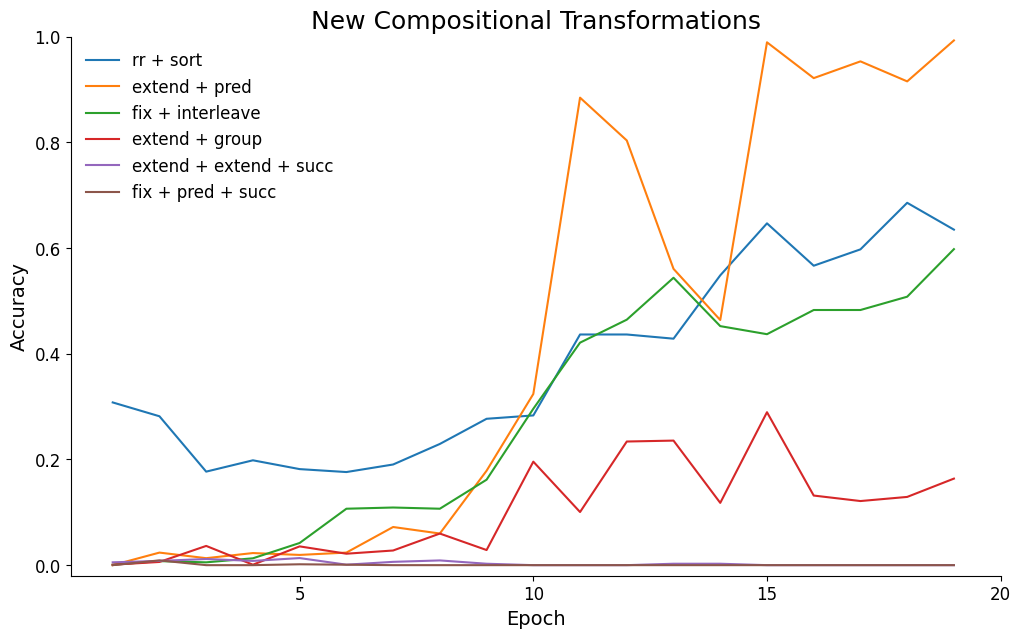

In [3]:
# Figure 5:
val_acc = pd.DataFrame(best_cp.val_acc_hist)
val_acc_by_gen = pd.melt(val_acc, id_vars=['epoch'], value_vars=[generate_data.ALL_TRANSFORMATIONS[i]["transformation"] for i in range(1,20)], var_name="transformation", value_name="accuracy")
trans2idx = {trans["transformation"]: idx for idx, trans in generate_data.ALL_TRANSFORMATIONS.items()}
val_acc_by_gen["generalization"] = val_acc_by_gen.transformation.apply(
        lambda x: generate_data.ALL_TRANSFORMATIONS[trans2idx[str(x)]]["generalization_type"]
)
val_acc_by_gen["transformation"] = val_acc_by_gen["transformation"].apply(lambda x: x.replace("_", " + "))
# fig, ax = plt.subplots(3, 1, figsize=(8,16))
# for i, gen_type in enumerate([0,2,3]):
_ = plt.figure(figsize=(12,7))
_ = sns.lineplot(data=val_acc_by_gen[val_acc_by_gen.generalization==2], x="epoch", y="accuracy", hue="transformation")
_ = plt.title("New Compositional Transformations")
_ = plt.xticks([5, 10, 15, 20])
_ = plt.ylim((-0.02,1))
_ = plt.xlabel("Epoch")
_ = plt.ylabel("Accuracy")

_ = plt.legend(loc='upper left', fontsize=12)

Training information:
Best Validation Loss: 0.604
Best Validation Accuracy: 0.717


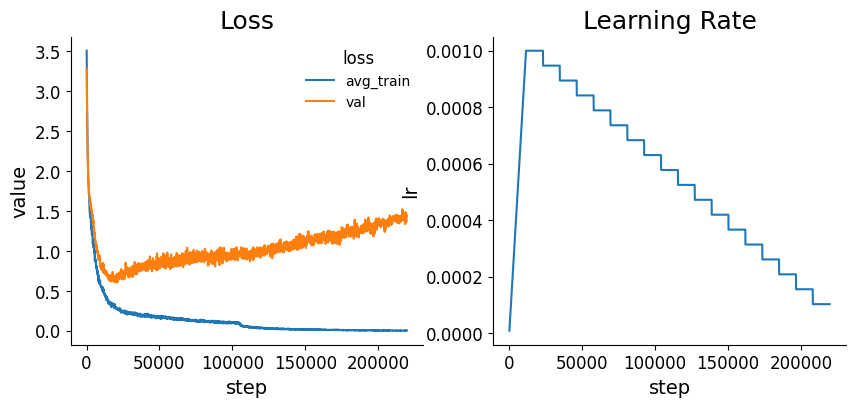

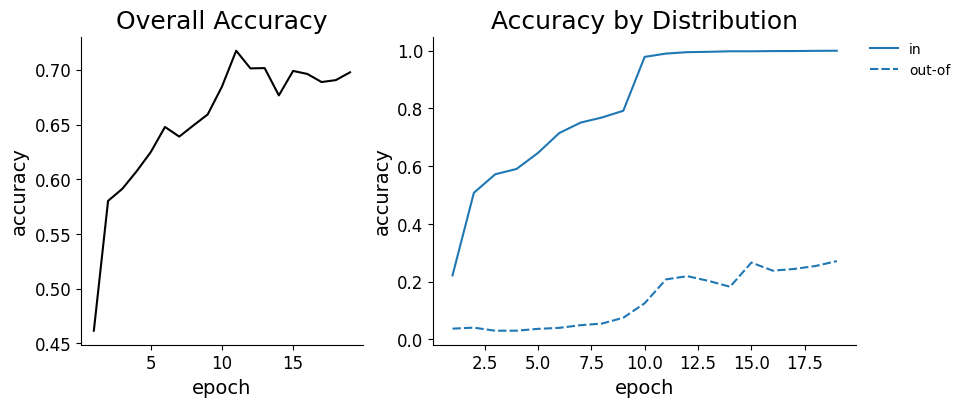

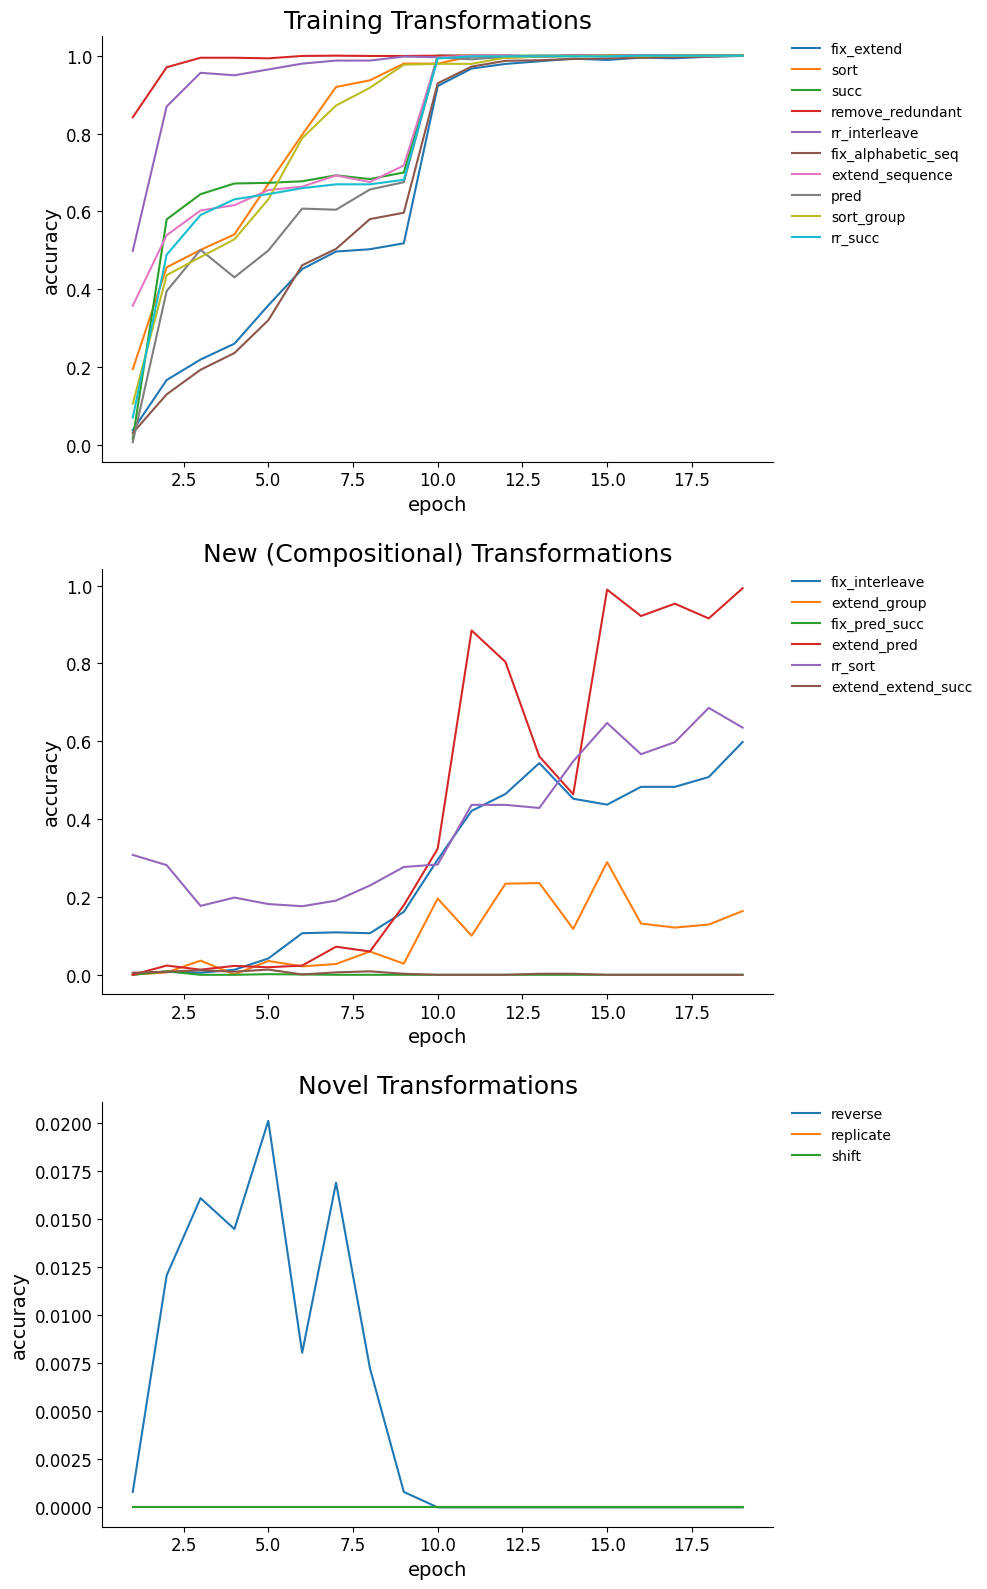

In [4]:
val = best_cp.load_dataloaders(data_dir=f"../{best_cp.train_config.dir_data}", verbose=False, use_datasets=["val"])[0]
_ = analysis_utils.training_history(best_cp, val)

### Assess Predictions Best Model

In [ ]:
# take best model and extract predictions for new rules:
best_model = all_rand_runs[0].load_model()
pred = analysis_utils.predict_dataset(test_new_alph, best_model, alternative_rule_errors=False)

#### Export Predictions of Best Model
- Errors were manually graded after exporting predictions

In [ ]:
false_pred_samples = pred[(~pred.correct) & (pred.distribution=="out-of")].groupby("transformation").sample(5, replace=True)
false_pred_samples[
        ["transformation", "n_perm", "alphabet", "study", "problem", "pred"]
    ].to_csv("predictions/false_predictions_new_trans_best_model.csv", index=False)